# Tarea 03 – Uso de una red neuronal entrenada

***

## Descripción

En esta actividad haremos uso de las bibliotecas Keras y TensorFlow o TensorFlow-GPU para extraer la información de una serie de imágenes, entregar a una red neuronal con dicha información y clasificar imágenes. En particular, el conjunto de datos es sobre deportes, y aunque están a una muy baja resolución, el procedimiento es el mismo. La idea es poder ejecutar en su equipo la red neuronal, para que en un futuro se pueda utilizar con otras imágenes.

***

## Objetivo

Comprender la creación y entrenamiento de una red neuronal para reconocimiento de patrones. Hacer uso 
de la información del modelo en la identificación de objetos

***

## Tecnologías usadas

Keras, TensorFlow con DirectML (GPU), numpy, matplotlib y sklearn

***

## Instalación de librerías


In [2]:
# Instalación de bibliotecas
%pip install keras tensorflow-directml numpy matplotlib scikit-learn

# Versión de Python, SO y librerías instaladas
import sys
import platform
import numpy as np
import matplotlib
import tensorflow as tf
import keras
import sklearn

print(f"Sistema Operativo : {platform.system()} {platform.release()} ({platform.version()})")
print(f"Python            : {sys.version}")
print(f"TensorFlow        : {tf.__version__}")
print(f"Keras             : {keras.__version__}")
print(f"Scikit-learn      : {sklearn.__version__}")
print(f"NumPy             : {np.__version__}")
print(f"Matplotlib        : {matplotlib.__version__}")

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow-directml (from versions: none)
ERROR: No matching distribution found for tensorflow-directml


Sistema Operativo : Windows 10 (10.0.19045)
Python            : 3.13.7 (tags/v3.13.7:bcee1c3, Aug 14 2025, 14:15:11) [MSC v.1944 64 bit (AMD64)]
TensorFlow        : 2.21.0
Keras             : 3.14.0
Scikit-learn      : 1.7.2
NumPy             : 2.3.3
Matplotlib        : 3.10.7


## Importar Librerías

In [3]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

import tensorflow as tf
import keras
from keras.utils import to_categorical
from keras.models import Sequential, Model
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import BatchNormalization
from keras.layers import LeakyReLU
from skimage.transform import resize

## Cargar set de Imágenes

>descargar set de imagenes de [aquí](https://drive.google.com/drive/folders/1O8W3QDiTSaNn3c4fA-YMt7hi1H1SVASp?usp=sharing)

In [8]:
dirname = os.path.join(os.getcwd(), 'sportimages')
imgpath = dirname + os.sep 

images = []
directories = []
dircount = []

print("leyendo imagenes de ", imgpath)

for root, dirnames, filenames in os.walk(imgpath):
    image_files = [f for f in filenames if re.search(r"\.(jpg|jpeg|png|bmp|tiff)$", f, re.IGNORECASE)]
    if not image_files:
        continue

    directories.append(root)
    cant = 0
    print(f"Procesando carpeta: {root}")

    for filename in image_files:
        filepath = os.path.join(root, filename)
        image = plt.imread(filepath)
        images.append(image)
        cant += 1
        print(f"Leyendo... {cant}", end="\r")

    dircount.append(cant)
    print(f"{root} {cant}")

print('Directorios leídos:', len(directories))
print("Imagenes en cada directorio", dircount)
print('suma Total de imagenes en subdirs:', sum(dircount))

leyendo imagenes de  c:\Users\sebas\Documents\Maestría en IA\Practicas\Cuatrimestre 2\4 - Percepción Computacional\Tarea 03\sportimages\
Procesando carpeta: c:\Users\sebas\Documents\Maestría en IA\Practicas\Cuatrimestre 2\4 - Percepción Computacional\Tarea 03\sportimages\americano
c:\Users\sebas\Documents\Maestría en IA\Practicas\Cuatrimestre 2\4 - Percepción Computacional\Tarea 03\sportimages\americano 9348
Procesando carpeta: c:\Users\sebas\Documents\Maestría en IA\Practicas\Cuatrimestre 2\4 - Percepción Computacional\Tarea 03\sportimages\basket
c:\Users\sebas\Documents\Maestría en IA\Practicas\Cuatrimestre 2\4 - Percepción Computacional\Tarea 03\sportimages\basket 8823
Procesando carpeta: c:\Users\sebas\Documents\Maestría en IA\Practicas\Cuatrimestre 2\4 - Percepción Computacional\Tarea 03\sportimages\beisball
c:\Users\sebas\Documents\Maestría en IA\Practicas\Cuatrimestre 2\4 - Percepción Computacional\Tarea 03\sportimages\beisball 7752
Procesando carpeta: c:\Users\sebas\Documents\M

In [9]:
labels=[]
indice=0
for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice=indice+1
print("Cantidad etiquetas creadas: ", len(labels))

Cantidad etiquetas creadas:  77128


In [10]:
deportes = []
for directorio in directories:
    name = directorio.split(os.sep)
    deportes.append(name[-1])
print(list(enumerate(deportes)))

[(0, 'americano'), (1, 'basket'), (2, 'beisball'), (3, 'boxeo'), (4, 'ciclismo'), (5, 'f1'), (6, 'futbol'), (7, 'golf'), (8, 'natacion'), (9, 'tenis')]


In [7]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8) # convierto de lista a numpy

# Find the unique numbers from the train labels
classes = np.unique(y)
nClasses = len(classes)
print('Total number of outputs : ', nClasses)
print('Output classes : ', classes)

Total number of outputs :  10
Output classes :  [0 1 2 3 4 5 6 7 8 9]


In [8]:
# test_size=0.2 reserva el 20% de los datos para prueba y usa el 80% restante para entrenamiento
train_X, test_X, train_Y, test_Y = train_test_split(X, y, test_size=0.2, random_state=13)

print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)
# X.shape = (<cantidad de imagenes>, <Resolución x>, <Resolución y>, <Canales de color (3 = RGB)>)

Training data shape :  (61702, 21, 28, 3) (61702,)
Testing data shape :  (15426, 21, 28, 3) (15426,)


## Preprocesamos las imagenes

In [9]:
train_X = train_X.astype("float32")
test_X = test_X.astype("float32")
train_X = train_X / 255.
test_X = test_X / 255.

## Normalización

Los píxeles originales son enteros en el rango `[0, 255]`. Al dividir entre 255 los llevamos al rango `[0.0, 1.0]`. Esto beneficia al entrenamiento porque:

- Los gradientes tienen magnitudes similares en todas las capas, lo que estabiliza el descenso por gradiente.
- El optimizador Adam asume que las entradas están en rangos razonables; valores grandes pueden causar explosión de gradientes.

Sin normalización el modelo igual podría aprender, pero tardaría más y con mayor riesgo de inestabilidad numérica.

## Hacemos el One-hot Encoding para la red

In [10]:
# Change the labels from categorical to one-hot encoding
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

print("Original label:", train_Y[0])
print("After conversion to one-hot:", train_Y_one_hot[0])

Original label: 7
After conversion to one-hot: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


La capa de salida de la red tiene **10 neuronas** (una por deporte) y usa `softmax`, que produce un vector de 10 probabilidades que suman 1. Para que la función de pérdida `categorical_crossentropy` pueda comparar esa salida con la etiqueta real, ambas deben tener la misma forma — de ahí el one-hot encoding.

Comparar directamente con un entero (e.g., `7`) no funciona con cross-entropy; la conversión a `[0,0,0,0,0,0,0,1,0,0]` lo hace posible.

## Creamos el Set de Entrenamiento y Validación

In [11]:
train_X, valid_X, train_label, valid_label = train_test_split(
    train_X, train_Y_one_hot, test_size=0.2, random_state=13
)
print(train_X.shape, valid_X.shape, train_label.shape, valid_label.shape)

(49361, 21, 28, 3) (12341, 21, 28, 3) (49361, 10) (12341, 10)


El dataset se divide **dos veces** con roles distintos:

| Subconjunto | Tamaño | Cuándo se usa |
|-------------|--------|---------------|
| **Test** (1ª división) | 15,426 | Una única vez al final, para la evaluación final honesta |
| **Validación** (2ª división) | 12,341 | Al final de cada época para detectar sobreajuste |
| **Entrenamiento** (2ª división) | 49,361 | En cada batch para actualizar los pesos |

Si se usara el set de test para monitorear el entrenamiento, los resultados finales ya no serían honestos — el modelo habría sido influenciado por esos datos de forma indirecta.

## Creamos el modelo de CNN

In [12]:
INIT_LR = 1e-3
epochs = 20
batch_size = 64

## Hiperparámetros del entrenamiento

- **`INIT_LR = 1e-3`** — learning rate inicial; controla qué tan grandes son los pasos de actualización de pesos. Un valor muy alto hace que el modelo diverja; uno muy bajo, que aprenda demasiado lento.
- **`epochs = 20`** — número de veces que el modelo recorre todo el dataset de entrenamiento.
- **`batch_size = 64`** — cuántas imágenes procesa a la vez antes de actualizar los pesos. Batches más grandes son más estables pero consumen más memoria.

In [13]:
# Modelo de red neuronal convolucional simple para clasificación de imágenes
sport_model = Sequential()

# Capa convolucional: extrae características locales con 32 filtros 3x3
sport_model.add(Conv2D(32, kernel_size=(3, 3), activation='linear', padding='same', input_shape=(21,28,3)))
# Activación no lineal para añadir capacidad de aprendizaje
sport_model.add(LeakyReLU(negative_slope=0.1))

# Reduce el tamaño espacial y mantiene las características más importantes
sport_model.add(MaxPooling2D((2, 2), padding='same'))
# Dropout para evitar sobreajuste, apaga aleatoriamente el 50% de las neuronas
sport_model.add(Dropout(0.5))
# Convierte la salida 2D a un vector 1D para las capas densas
sport_model.add(Flatten())

# Capa completamente conectada con 32 neuronas para combinar características
sport_model.add(Dense(32, activation='linear'))
# Activación no lineal después de la capa densa
sport_model.add(LeakyReLU(negative_slope=0.1))
# Dropout adicional para ayudar a generalizar mejor
sport_model.add(Dropout(0.5))

# Capa de salida con una neurona por cada clase y softmax para probabilidades
sport_model.add(Dense(nClasses, activation='softmax'))

sport_model.summary()

c:\Users\sebas\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 21, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 21, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       157,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,954 (620.91 KB)

 Trainable params: 158,954 (620.91 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
sport_model.compile(
    loss=keras.losses.categorical_crossentropy,
    optimizer=keras.optimizers.Adam(learning_rate=INIT_LR),
    metrics=["accuracy"]
)

- **`categorical_crossentropy`** — función de pérdida estándar para clasificación multiclase. Mide cuán diferente es el vector de probabilidades predicho del vector one-hot real.
- **`Adam`** — optimizador que adapta el learning rate de cada peso individualmente usando promedios móviles exponenciales del gradiente. A diferencia de Adagrad (que acumula todos los gradientes y eventualmente deja de aprender), Adam "olvida" gradientes viejos, manteniendo el aprendizaje activo durante todo el entrenamiento.

## Entrenamos el modelo: Aprende a clasificar imágenes

In [15]:
sport_train = sport_model.fit(
    train_X, train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(valid_X, valid_label)
)

Epoch 1/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7624 - loss: 0.7371 - val_accuracy: 0.9344 - val_loss: 0.2406
Epoch 2/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8946 - loss: 0.3369 - val_accuracy: 0.9592 - val_loss: 0.1372
Epoch 3/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9222 - loss: 0.2523 - val_accuracy: 0.9718 - val_loss: 0.0996
Epoch 4/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9350 - loss: 0.2116 - val_accuracy: 0.9798 - val_loss: 0.0745
Epoch 5/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9417 - loss: 0.1814 - val_accuracy: 0.9754 - val_loss: 0.0844
Epoch 6/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9486 - loss: 0.1619 - val_accuracy: 0.9835 - val_loss: 0.0538
Epoch 7/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9530 - loss: 0.1491 - val_accuracy: 0.9838 - val_loss: 0.0552
Epoch 8/20
772/772 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9551 - loss: 0.1392 - val_accuracy: 0.

Cada línea del log muestra el estado al final de esa época. Una señal de **sobreajuste** sería que `accuracy` en entrenamiento siga subiendo mientras `val_accuracy` se estanca o baja. Aquí ambas suben en paralelo, lo que indica que el modelo generaliza bien — el `Dropout(0.5)` cumple su función de regularización.

In [16]:
# guardamos la red, para reutilizarla en el futuro, sin tener que volver a entrenar
sport_model.save("sports_mnist.keras")

In [5]:
# Para cargar el modelo guardado sin necesidad de volver a entrenar
sport_model = keras.models.load_model("sports_mnist.keras")

## Evaluamos la red

In [18]:
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)

483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9891 - loss: 0.0330


In [19]:
print('Test loss:', test_eval[0])
print('Test accuracy:', test_eval[1])

Test loss: 0.03303493559360504
Test accuracy: 0.9891092777252197


In [20]:
predicted_classes2 = sport_model.predict(test_X)

483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [21]:
predicted_classes = []
for predicted_sport in predicted_classes2:
    predicted_classes.append(predicted_sport.tolist().index(max(predicted_sport)))
predicted_classes = np.array(predicted_classes)

In [22]:
predicted_classes.shape, test_Y.shape

((15426,), (15426,))

Found 15258 correct labels


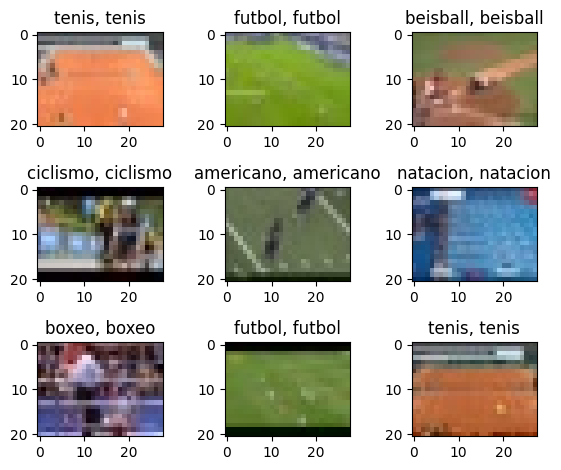

In [23]:
correct = np.nonzero(predicted_classes==test_Y)[0]
print("Found %d correct labels" % len(correct))
for i, correct in enumerate(correct[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[correct].reshape(21,28,3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[correct]],
                                                    deportes[test_Y[correct]]))

    plt.tight_layout()

Found 168 incorrect labels


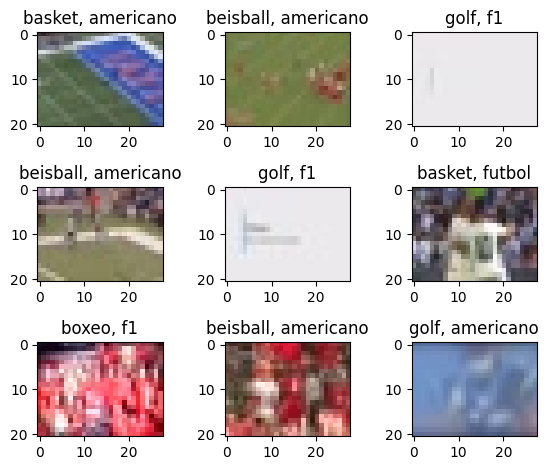

In [24]:
incorrect = np.nonzero(predicted_classes != test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))
for i, incorrect in enumerate(incorrect[0:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(test_X[incorrect].reshape(21,28,3), cmap="gray", interpolation="none")
    plt.title("{}, {}".format(deportes[predicted_classes[incorrect]],
                               deportes[test_Y[incorrect]]))
    plt.tight_layout()

In [25]:
target_names = ["Class {}".format(i) for i in range(nClasses)]
print(classification_report(test_Y, predicted_classes, target_names=target_names))

              precision    recall  f1-score   support

     Class 0       0.99      0.96      0.97      1799
     Class 1       0.99      1.00      0.99      1762
     Class 2       0.97      1.00      0.99      1597
     Class 3       0.99      1.00      1.00      1428
     Class 4       1.00      1.00      1.00      1464
     Class 5       0.99      0.96      0.97      1014
     Class 6       1.00      0.99      0.99      1569
     Class 7       0.97      0.99      0.98      1976
     Class 8       1.00      1.00      1.00      1030
     Class 9       1.00      1.00      1.00      1787

    accuracy                           0.99     15426
   macro avg       0.99      0.99      0.99     15426
weighted avg       0.99      0.99      0.99     15426



In [16]:
images=[]

# deportes = ['americano', 'basket', 'beisball', 'boxeo', 'ciclismo', 'f1', 'futbol', 'golf', 'natacion', 'tenis']

# AQUÍ ESPECIFICAMOS UNAS IMAGENES
filenames = ['sportimages/golf/golf_0113.jpg']

for filepath in filenames:
    image = plt.imread(filepath,0)
    image_resized = resize(image, (21, 28), anti_aliasing=True, clip=False, preserve_range=True)
    images.append(image_resized)

X = np.array(images, dtype=np.uint8) #convierto de lista a numpy
test_X = X.astype('float32')
test_X = test_X / 255.

predicted_classes = sport_model.predict(test_X)

for i, img_tagged in enumerate(predicted_classes):
    print(filenames[i], deportes[img_tagged.tolist().index(max(img_tagged))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
sportimages/golf/golf_0113.jpg golf


## Referencias

### Set de imágenes

1. [Set de imágenes de deportes (Google Drive)](https://drive.google.com/drive/folders/1O8W3QDiTSaNn3c4fA-YMt7hi1H1SVASp?usp=sharing)

### Librerías

2. [TensorFlow](https://www.tensorflow.org/)
3. [Keras](https://keras.io/)
4. [NumPy](https://numpy.org/)
5. [Matplotlib](https://matplotlib.org/)
6. [scikit-learn](https://scikit-learn.org/)
7. [scikit-image](https://scikit-image.org/)

### Repositorio

8. [Repositorio de GitHub con Jupyter Notebook de la Práctica](https://github.com/RKCbas/Maestria-en-Inteligencia-Artificial---Practicas/blob/main/Cuatrimestre%202/4%20-%20Percepción%20Computacional/Tarea%2003/Uso%20de%20una%20red%20neuronal%20entrenada.ipynb)